In [405]:
from src.reference import Reference
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.tools import MMSeqs
import requests
import re
from tqdm import tqdm
import os
from scipy.stats import f_oneway
from sklearn.metrics import r2_score, euclidean_distances
from src.dataset import Dataset
from src.graph import NeighborsGraph
import subprocess
import matplotlib.cm as cm 
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

from src.files import FASTAFile, InterProScanFile
from sklearn.decomposition import PCA

%load_ext autoreload 
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [312]:
model_name = 'model_v2'

train_results_df = pd.read_csv('../data/results/dataset_train_predict.csv', index_col=0).assign(dataset='train')
test_results_df = pd.read_csv('../data/results/dataset_test_predict.csv', index_col=0).assign(dataset='test')

results_df = pd.concat([train_results_df, test_results_df])
results_df = results_df.rename(columns={f'{model_name}_output_0':'model_output_0', f'{model_name}_output_1':'model_output_1', f'{model_name}_label':'model_label'})[['model_label', 'model_output_0', 'model_output_1', 'dataset']].copy()
results_df = results_df.merge(pd.read_csv('../data/datasets/dataset.csv', index_col=0), left_index=True, right_index=True)

In [419]:
def get_amino_acid_composition(df:pd.DataFrame, reduce:bool=True):
    df = df.copy()
    
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'    
    # https://academic.oup.com/peds/article/16/5/323/1542677?login=true
    reduced_alphabet = {'F':'Y', 'W':'Y', 'Y':'Y', 'M':'L', 'L':'L', 'I':'V', 'V':'V', 'C':'A', 'A':'A', 'T':'T', 'T':'S', 'N':'N', 'H':'N', 'P':'P', 'G':'G', 'D':'D', 'E':'D', 'Q':'K', 'R':'K', 'K':'K'}
    amino_acids = list(reduced_alphabet.values()) if reduce else set(amino_acids)
    amino_acids = sorted(amino_acids) # Ensure consistent ordering. 

    def reduce_(seq:str):
        for aa, rep_aa in reduced_alphabet.items():
            seq = seq.replace(aa, rep_aa) # Replace each amino acid with its representative. 
        return seq

    if reduce:
        df['seq'] = df.seq.apply(reduce_)
        
    comp_df = [{aa:seq.count(aa) / len(seq) for aa in list(amino_acids)} for seq in df.seq]
    comp_df = pd.DataFrame(comp_df, index=df.index)[amino_acids]
    return comp_df

In [ ]:
def get_nuccore(nuccore_ids, chunk_size=50, dir_='../data/results/rpoz/gbffs'):
    pbar = tqdm(total=len(nuccore_ids), desc='get_nuccore')
    nuccore_ids = np.array_split(nuccore_ids, len(nuccore_ids) // chunk_size + 1)

    for ids in nuccore_ids:
        url = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={ids}&rettype=gbwithparts&retmode=text'.format(ids=','.join(ids))
        content = requests.get(url).text
        for id_, content_ in zip(ids, re.split('(?=LOCUS)', content)[1:]): # Split by LOCUS so that each is written individually to a file. 
            with open(os.path.join(dir_, f'{id_}_genomic.gbff'), 'w') as f:
                f.write(content_)
        pbar.update(len(ids))

In [440]:
def get_structures(ids, dir_='../data/results/rpoz/pdbs'):
    version = 4 # Not sure if this version will always work. 
    for id_ in tqdm(ids, desc='get_structures'):
        url = f'https://alphafold.ebi.ac.uk/files/AF-{id_}-F1-model_v{version}.pdb'
        output_path = os.path.join(dir_, f'{id_}.pdb')
        if not os.path.exists(output_path):
            subprocess.run(f'wget {url} -O {output_path}', shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
get_structures(rpoz_results_df.index)

get_structures:   0%|          | 0/429 [00:00<?, ?it/s]

get_structures: 100%|██████████| 429/429 [02:04<00:00,  3.44it/s] 


In [ ]:
def load_msa(path:str, start:int=None, stop:int=None, consensus:bool=True, join:bool=True):
    df = FASTAFile(path=path).to_df(prodigal_output=False)
    msa = np.array([list(seq) for seq in df.seq]) 
    if consensus: # Load only the regions convered in the alignment. 
        msa = msa[:, ~np.any(msa == '-', axis=0)]
    if (start is not None) and (stop is not None):
        msa = msa[:, start:stop]
    return pd.DataFrame({'seq':[''.join(seq) for seq in msa]}, index=df.index) if join else pd.DataFrame(msa, index=df.index)

In [ ]:
def get_distances(dataset:Dataset, subject_ids:list=None):
    subject_ids = dataset.index if (subject_ids is None) else subject_ids
    embeddings_df = pd.DataFrame(dataset.numpy(), index=dataset.index)
    dist_df = list()
    for query_id in dataset.index:
        query_embedding = np.expand_dims(embeddings_df.loc[query_id].values, axis=0)
        subject_embeddings = embeddings_df.loc[subject_ids].values
        dists = euclidean_distances(query_embedding, subject_embeddings).ravel()
        dist_df += [{'query_id':query_id, 'subject_id':subject_id, 'distance':dist} for subject_id, dist in zip(subject_ids, dists)]
    return pd.DataFrame(dist_df)


## DNA-directed RNA polymerase subunit omega (rpoZ)

In [420]:
rpoz_results_df = results_df[results_df['product'] == 'DNA-directed RNA polymerase subunit omega'].copy()
rpoz_results_df.to_csv('../data/results/rpoz/rpoz.csv')
FASTAFile(df=rpoz_results_df).write('../data/results/rpoz/rpoz.faa')

threshold = 0.95
rpoz_real_ids = rpoz_results_df[rpoz_results_df.model_output_1 > threshold].index.values # Get IDs for sequences predicted real with a high probability. 
rpoz_spurious_ids = rpoz_results_df[rpoz_results_df.model_output_0 > threshold].index.values # Get IDs for sequences predicted spurious with a high probability. 
print(len(rpoz_real_ids), f'rpoZ sequences predicted real with >{threshold} certainty.')

379 rpoZ sequences predicted real with >0.95 certainty.


In [ ]:
# Some possible characteristics to check if the flagged spurious sequences have any notable differences. 
# (1) Amino acid composition. 
# (2) Length. 
# (3) Structure. 


In [436]:
rpoz_comp_df = get_amino_acid_composition(rpoz_results_df, reduce=True)

pca = PCA(n_components=10)
components = pca.fit_transform(rpoz_comp_df.values)
print(sum(pca.explained_variance_ratio_))

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = cm.ScalarMappable(norm=norm, cmap=cm.coolwarm)

for i, component in enumerate(components.T):
    print(i, r2_score(component, rpoz_results_df.model_output_0))
# sns.scatterplot(x=components[:, 0].ravel(), y=components[:, 1].ravel(), c=rpoz_results_df.model_output_0, cmap='coolwarm')

0.9999999999999999
0 -4.572085323585985
1 -10.221341775045376
2 -13.496678557559077
3 -17.82864258756576
4 -35.289592804785556
5 -36.528511087284095
6 -43.959520090204975
7 -98.92890606223929
8 -148.9910490390765
9 -1.9328138220086096e+31


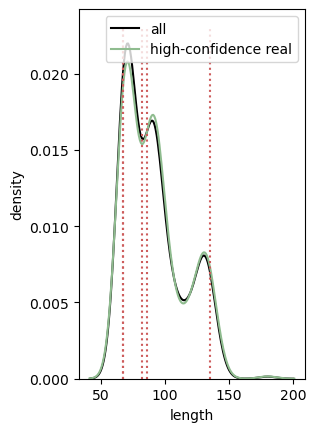

In [412]:
# Should have a figure characterizing the family, as well as any potential differences in the sequences which were predicted spurious. 

def figure(results_df:pd.DataFrame):
    
    spurious_ids = results_df.index[results_df.model_output_0 > 0.95]
    
    fig = plt.figure()
    grid = GridSpec(nrows=1, ncols=2, figure=fig)

    ax_a = fig.add_subplot(grid[0, 0])
    sns.kdeplot(x=results_df.seq.apply(len), label='all', color='black')
    sns.kdeplot(x=results_df[results_df.model_output_1 > 0.95].seq.apply(len), label='high-confidence real', color='darkseagreen')
    ax_a.vlines(results_df.loc[spurious_ids].seq.apply(len), ymin=0, ymax=ax_a.get_ylim()[-1], color='indianred', ls=':')
    ax_a.set_xlabel('length')
    ax_a.set_ylabel('density')
    ax_a.legend()

    plt.show()
    fig.tight_layout()

figure(rpoz_results_df)

In [ ]:
#  ~/muscle5.1.linux_intel64 -align rpoz.faa -output rpoz.afa
# rpoz_msa_df = load_msa('../data/results/rpoz/rpoz.afa', consensus=True, join=False)

In [ ]:
mmseqs = MMSeqs(dir_='../data/mmseqs')
rpoz_align_df = mmseqs.align(query_df=rpoz_results_df, query_name='rpoz', sensitivity=15, output_dir='../data/results/rpoz', max_e_value=100, overwrite=False)
rpoz_align_df = rpoz_align_df[rpoz_align_df.subject_id.isin(rpoz_real_ids)].copy()

print(len(rpoz_align_df), 'out of', len(rpoz_align_df), 'proteins can be aligned to a high-confidence real protein.')

116888 out of 116888 proteins can be aligned to a high-confidence real protein.


In [ ]:
rpoz_dataset = Dataset.from_hdf('../data/results/rpoz/rpoz.h5')
rpoz_dist_df = get_distances(rpoz_dataset, subject_ids=rpoz_real_ids)

NeighborsGraph.get_graph: 117358it [00:00, 710135.12it/s]


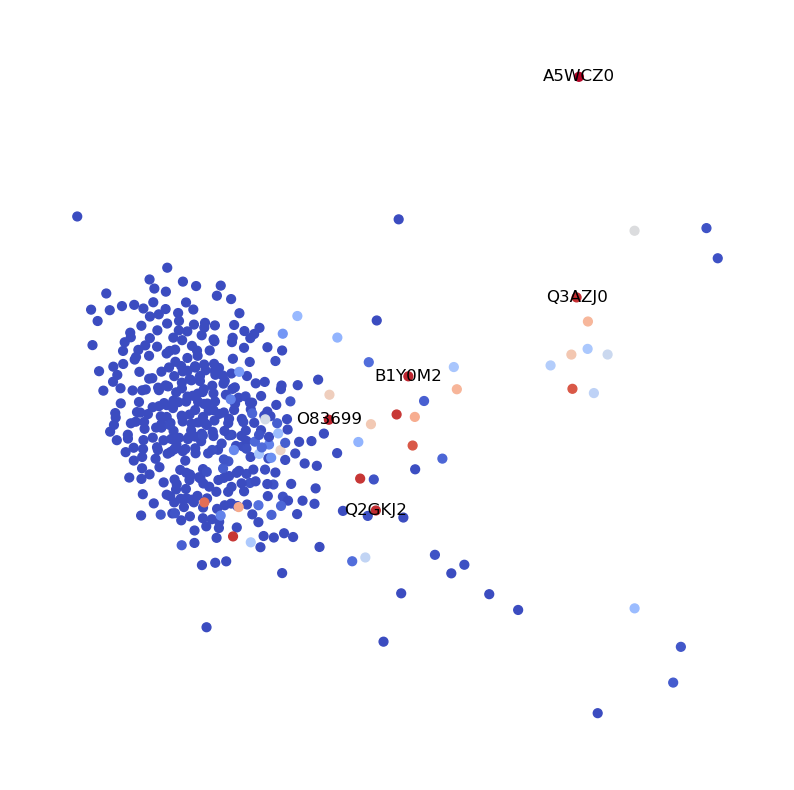

In [401]:
graph = NeighborsGraph.load('../data/results/rpoz/rpoz_graph.pkl')

fig, ax = plt.subplots(figsize=(10, 10))
colors = {row.Index:'darkseagreen' if (row.model_output_1 > 0.5) else 'khaki' for row in results_df.itertuples()}
colors = {row.Index:'darkseagreen' if (row.product == 'DNA-directed RNA polymerase subunit omega') else 'black' for row in results_df.itertuples()}
colors.update({id_:'indianred' for id_ in rpoz_spurious_ids})

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = cm.ScalarMappable(norm=norm, cmap=cm.coolwarm)
colors = {row.Index:cmap.to_rgba(row.model_output_0) for row in results_df.itertuples()}
# colors.update({row.Index:'indianred' if (row.model_output_0 > 0.95) else 'khaki' for row in results_df.itertuples()})

graph.draw(subset_ids=rpoz_results_df.index, colors=colors, labels=rpoz_spurious_ids, ax=ax)
plt.show()

In [389]:
print(rpoz_spurious_ids)
graph.get_neighbor_metadata('O83699')

['B1Y0M2' 'Q3AZJ0' 'A5WCZ0' 'O83699' 'Q2GKJ2']


,model_label,model_output_0,model_output_1,dataset,domain,lineage,species,ncbi_taxonomy_id,refseq_protein_id,refseq_nucleotide_id,...,antifam_description,antifam_id,product,seq,existence,name,file_name,library_entry_name,label,distance
id,,,,,,,,,,,,,,,,,,,,,
A2SJD1,0,5.856586e-01,0.414341,train,Bacteria,Bacteria;Pseudomonadota;Betaproteobacteria;Bur...,RPOZ_METPP,420662,WP_011830300.1,NC_008825.1,...,none,none,DNA-directed RNA polymerase subunit omega,MARITVEDCLTKIPNRFQLVLAATYRARMLSQGHAPKVESKNKPGV...,inferred from homology,RPOZ_METPP,swissprot.xml,swissprot_bacteria,1,1.313953
B1Y0M2,0,9.713818e-01,0.028618,train,Bacteria,Bacteria;Pseudomonadota;Betaproteobacteria;Bur...,RPOZ_LEPCP,395495,WP_012345765.1,NC_010524.1,...,none,none,DNA-directed RNA polymerase subunit omega,MARITVEDCLQKIPNRFQLVLAATYRARMLSQGHAPKVETKNKPGV...,inferred from homology,RPOZ_LEPCP,swissprot.xml,swissprot_bacteria,1,1.330904
A9ILJ1,0,5.586623e-01,0.441338,train,Bacteria,Bacteria;Pseudomonadota;Betaproteobacteria;Bur...,RPOZ_BORPD,340100,none,none,...,none,none,DNA-directed RNA polymerase subunit omega,MARITVEDCLNQVPNRFKLTLAATYRARELAQGHAPRIDSKDKPTV...,inferred from homology,RPOZ_BORPD,swissprot.xml,swissprot_bacteria,1,1.353755
Q7VXZ4,1,4.616240e-01,0.538376,test,Bacteria,Bacteria;Pseudomonadota;Betaproteobacteria;Bur...,RPOZ_BORPE,257313,NP_880310.1,NC_002929.2,...,none,none,DNA-directed RNA polymerase subunit omega,MARITVEDCLNQIPNRFKLTLAATYRARELVQGHAPRLDSKDKPTV...,inferred from homology,RPOZ_BORPE,swissprot.xml,swissprot_bacteria,1,1.375208
Q31MH9,1,4.202373e-02,0.957976,train,Bacteria,Bacteria;Bacillati;Cyanobacteriota;Cyanophycea...,RPOZ_SYNE7,1140,WP_011244691.1,NZ_JACJTX010000001.1,...,none,none,DNA-directed RNA polymerase subunit omega,MLQRFDLDSQDLLFKAESLIVNSTNRYHVTLQIARRAKQARYEEME...,evidence at protein level,RPOZ_SYNE7,swissprot.xml,swissprot_bacteria,1,1.407735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A8FD34,1,1.865084e-06,0.999998,train,Bacteria,Bacteria;Bacillati;Bacillota;Bacilli;Bacillale...,RPOZ_BACP2,315750,WP_003211647.1,NZ_VEIS01000003.1,...,none,none,DNA-directed RNA polymerase subunit omega,MLDPSIDSLMNKLDSKYTLVTVSARRAREMQIHQDQQIENTKSYKF...,inferred from homology,RPOZ_BACP2,swissprot.xml,swissprot_bacteria,1,1.991611
Q65RR6,1,2.228969e-05,0.999978,train,Bacteria,Bacteria;Pseudomonadota;Gammaproteobacteria;Pa...,RPOZ_MANSM,221988,WP_011200903.1,NC_006300.1,...,none,none,DNA-directed RNA polymerase subunit omega,MARVTVQDAVEKIGNRFDLILTAARRARQLQLHVREPLVPEDNDKP...,inferred from homology,RPOZ_MANSM,swissprot.xml,swissprot_bacteria,1,1.996097
Q28V32,1,6.731660e-07,0.999999,train,Bacteria,Bacteria;Pseudomonadota;Alphaproteobacteria;Rh...,RPOZ_JANSC,290400,WP_011453639.1,NC_007802.1,...,none,none,DNA-directed RNA polymerase subunit omega,MARVTVEDCVDKVPNRFELVMLASHRAREIAAGDPLTIDRDNDKNP...,inferred from homology,RPOZ_JANSC,swissprot.xml,swissprot_bacteria,1,1.997515


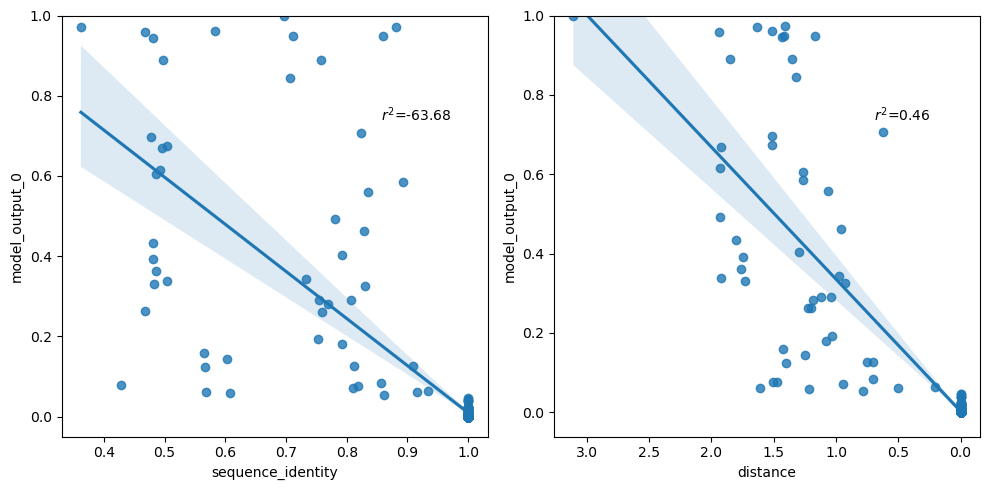

In [376]:
def figure(align_df:pd.DataFrame, dist_df:pd.DataFrame, results_df:pd.DataFrame):

    fig, (ax_a , ax_b) = plt.subplots(ncols=2, figsize=(10, 5))

    ax_a_df = align_df.copy().set_index('query_id')
    ax_a_df = ax_a_df.sort_values('sequence_identity', ascending=False)
    ax_a_df = ax_a_df[~ax_a_df.index.duplicated(keep='first')]
    ax_a_df['model_output_0'] = results_df.model_output_0

    # sns.scatterplot(data=ax_a_df, x='sequence_identity', y='model_output_0', ax=ax_a)
    sns.regplot(data=ax_a_df, x='sequence_identity', y='model_output_0', ax=ax_a)
    r2_score_a = r2_score(ax_a_df.sequence_identity, ax_a_df.model_output_0)
    ax_a.text(0.75, 0.75, f'$r^2$={r2_score_a:.2f}', transform=ax_a.transAxes)
    ax_a.set_ylim(ymax=1)

    ax_b_df = dist_df.copy().set_index('query_id')
    ax_b_df = ax_b_df.sort_values('distance', ascending=True)
    ax_b_df = ax_b_df[~ax_b_df.index.duplicated(keep='first')]
    ax_b_df['model_output_0'] = results_df.model_output_0

    # sns.scatterplot(data=ax_b_df, x='distance', y='model_output_0', ax=ax_b)
    sns.regplot(data=ax_b_df, x='distance', y='model_output_0', ax=ax_b)
    r2_score_b = r2_score(ax_b_df.distance, ax_b_df.model_output_0)
    ax_b.text(0.75, 0.75, f'$r^2$={r2_score_b:.2f}', transform=ax_b.transAxes)
    ax_b.invert_xaxis()
    ax_b.set_ylim(ymax=1)

    fig.tight_layout()
    plt.show()

figure(rpoz_align_df, rpoz_dist_df, rpoz_results_df)

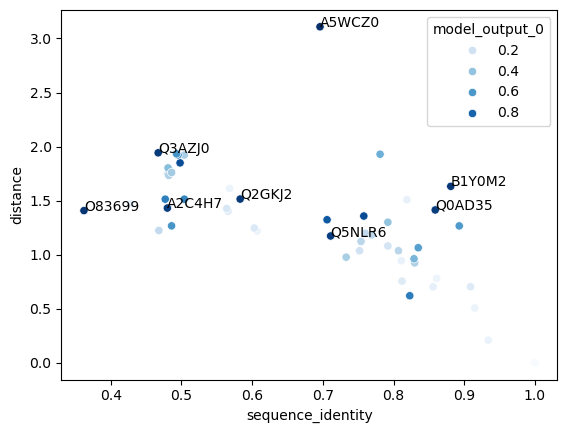

In [ ]:
def figure(align_df:pd.DataFrame, dist_df:pd.DataFrame, results_df:pd.DataFrame):

    threshold = 0.9
    fig, ax = plt.subplots()

    ax_df = pd.DataFrame(index=results_df.index)
    ax_df['distance'] = dist_df.sort_values('distance', ascending=True).drop_duplicates('query_id').set_index('query_id').distance
    ax_df['sequence_identity'] = align_df.sort_values('sequence_identity', ascending=False).drop_duplicates('query_id').set_index('query_id').sequence_identity
    ax_df['model_output_0'] = results_df.model_output_0

    sns.scatterplot(data=ax_df, x='sequence_identity', y='distance', hue='model_output_0', ax=ax, palette='Blues')

    spurious_ids = rpoz_results_df[results_df.model_output_0 > threshold].index.values # Get IDs for sequences predicted spurious with a high probability. 
    for id_ in spurious_ids:
        x, y = ax_df.loc[id_].sequence_identity, ax_df.loc[id_].distance,
        ax.text(x, y, id_)
    

In [ ]:
rpoz_weird_ids = ['Q5NLR6', 'Q0AD35', 'B1Y0M2']

# rpoz_align_df['query_length'] = rpoz_align_df.query_id.map(results_df.seq.apply(len))
# rpoz_align_df['subject_length'] = rpoz_align_df.subject_id.map(results_df.seq.apply(len))

min_sequence_identity = 0.7
for id_ in rpoz_weird_ids:
    ids = [id_] + list(rpoz_align_df[(rpoz_align_df.query_id == id_) & (rpoz_align_df.sequence_identity > min_sequence_identity)].subject_id)
    FASTAFile(df=results_df.loc[ids]).write(f'../data/results/rpoz/rpoz_{id_.lower()}.faa')
    subprocess.run(f' ~/muscle5.1.linux_intel64 -align ../data/results/rpoz/rpoz_{id_.lower()}.faa -output ../data/results/rpoz/rpoz_{id_.lower()}.afa', shell=True, check=True)

In [307]:
rpoz_align_df.sort_values('sequence_identity', ascending=False).drop_duplicates('query_id').set_index('query_id').loc[rpoz_spurious_ids]

,subject_id,sequence_identity,alignment_length,n_mismatches,n_gaps,query_alignment_start,query_alignment_stop,subject_alignment_start,subject_alignment_stop,e_value,bit_score
query_id,,,,,,,,,,,
Q0AD35,Q82SQ2,0.859,67,9,0,0,67,0,67,2.258000e-36,122
B1Y0M2,A9BTA2,0.881,67,8,0,0,67,0,67,1.304000e-37,125
A2C4H7,Q31MH9,0.480,76,36,0,0,70,0,76,2.980000e-18,70
Q3AZJ0,Q31MH9,0.467,82,40,0,0,82,0,76,5.668000e-19,73
A5WCZ0,Q4K3R3,0.696,59,18,0,0,59,0,59,3.643000e-23,85
O83699,Q15Z09,0.362,31,19,0,0,30,0,31,1.582000e-01,22
Q5NLR6,A7HX41,0.711,72,21,0,0,72,0,72,1.471000e-29,106
Q2GKJ2,Q3YSH8,0.583,81,33,0,0,81,0,81,2.098000e-25,94


In [311]:
rpoz_dist_df.sort_values('distance', ascending=True).drop_duplicates('query_id').set_index('query_id').loc[rpoz_spurious_ids]

,subject_id,distance
query_id,,
Q0AD35,B2IUW7,1.413815
B1Y0M2,Q8YNB9,1.632194
A2C4H7,Q8YNB9,1.431236
Q3AZJ0,C4K473,1.942247
A5WCZ0,Q6F7G9,3.108130
O83699,Q31MH9,1.407735
Q5NLR6,P58066,1.172854
Q2GKJ2,Q73FM5,1.514571


In [ ]:
def get_profile(msa_df:pd.DataFrame):
    profile = list()
    for position in range(len(msa_df.columns)):
        p = msa_df[position].value_counts()
        profile.append((p / p.sum()).to_dict())
    return profile

profile = get_profile(rpoz_msa_df)

def apply_profile(msa_df:pd.DataFrame, profile:list):
    msa_df = msa_df.copy()
    pd.set_option('future.no_silent_downcasting', True)
    for position in msa_df.columns:
        msa_df[position] = msa_df[position].replace(profile[position])
    return msa_df

def plot_profile(msa_df:pd.DataFrame, ax:plt.Axes=None):
    pass 

# sns.scatterplot, x='position', y='probability')
# sns.scatterplot(apply_profile(rpoz_msa_df.loc[rpoz_spurious_ids], profile).melt(var_name='position', value_name='probability'), x='position', y='probability')

# fig, ax = plt.subplots(figsize=(20, 5))
# ax_df = [apply_profile(rpoz_msa_df.loc[rpoz_real_ids], profile).melt(var_name='position', value_name='probability').assign(label='real')]
# ax_df += [apply_profile(rpoz_msa_df.loc[rpoz_spurious_ids], profile).melt(var_name='position', value_name='probability').assign(label='spurious')]
# ax_df = pd.concat(ax_df)

# positions = ax_df[ax_df.label == 'real'].mean(axis=1).values - ax_df[ax_df.label == 'real'].mean(axis=1).values
# ax_df = ax_df[ax_df.position.isin(positions)]

# sns.boxplot(data=ax_df, x='position', hue='label', y='probability', fill=False, gap=0.5, showfliers=False, palette={'real':'darkseagreen', 'spurious':'indianred'})
# plt.show()


In [ ]:
rpoz_interpro_df = InterProScanFile('../data/results/rpoz/rpoz_interpro.tsv').to_df()
# rpoz_interpro_df = rpoz_interpro_df.sort_values('interpro_e_value')[~rpoz_interpro_df.index.duplicated()]
rpoz_interpro_df = rpoz_interpro_df[~rpoz_interpro_df.interpro_analysis.isin(['MobiDBLite', 'Coils'])].copy()
rpoz_interpro_df['model_output_0'] = rpoz_interpro_df.index.map(rpoz_results_df.model_output_0)
rpoz_interpro_df['interpro_e_value'] = -np.log10(rpoz_interpro_df.interpro_e_value)
# rpoz_interpro_df['interpro_bit_score'] = rpoz_interpro_df.interpro_bit_score
rpoz_interpro_df['length'] = rpoz_results_df.seq.apply(len)

sns.scatterplot(data=rpoz_interpro_df, x='interpro_e_value', y='model_output_0', hue='interpro_analysis')

In [ ]:
rpoz_msa_df = load_msa('../data/results/rpoz/rpoz.afa', consensus=True, join=True)
rpoz_comp_df = pd.DataFrame([get_amino_acid_composition(seq) for seq in rpoz_msa_df.seq], index=rpoz_msa_df.index).fillna(0)
rpoz_comp_df = pd.DataFrame([get_amino_acid_composition(seq) for seq in rpoz_results_df.seq], index=rpoz_msa_df.index).fillna(0)

n_components = 15
rpoz_pca = PCA(n_components=n_components)
rpoz_components = rpoz_pca.fit_transform(rpoz_comp_df.values)

for i in range(n_components):
    score = r2_score(rpoz_components[:, i].ravel(), rpoz_results_df.model_output_0)
    print(i, score)


# sns.scatterplot(x=rpoz_components[:, 1].ravel(), y=rpoz_components[:, 2].ravel(), c=rpoz_results_df.model_label)

# How can I determine if there is a position that contributes more than others to the output value?

0 -14.609142618961355
1 -22.525937307137163
2 -30.847749014173075
3 -34.81972845424212
4 -42.920243285974955
5 -52.20558937926298
6 -65.15271991570003
7 -77.90466825336634
8 -87.02437268872313
9 -89.66850680310426
10 -126.6305850476739
11 -146.37660545404694
12 -172.34084021640163
13 -218.0741508222536
14 -239.04705202084932


In [ ]:
align_df['subject_model_label'] = align_df.subject_id.map(rpoz_results_df.model_label)
align_df['subject_model_output_1'] = align_df.subject_id.map(rpoz_results_df.model_output_1)
align_df = align_df[align_df.subject_model_label == 1].copy()
align_df = align_df.sort_values('sequence_identity', ascending=False)
align_df = align_df[~align_df.index.duplicated(keep='first')]

In [ ]:
# rpoz_results_df.sort_values('model_output_0').index[0]
# The DNA-directed RNA polymerase subunit omega with the lowest value for model_output_0 is A6Q312. 
# rpoz_representative = 'A6Q312'
# rpoz_results_df['identity_to_representative'] = align_df[align_df.subject_id == rpoz_representative].sequence_identity
# rpoz_results_df['identity_to_representative'] = rpoz_results_df.identity_to_representative.fillna(0)

rpoz_results_df['highest_identity_to_correct'] = align_df.sequence_identity
rpoz_results_df['highest_bit_score_to_correct'] = align_df.bit_score

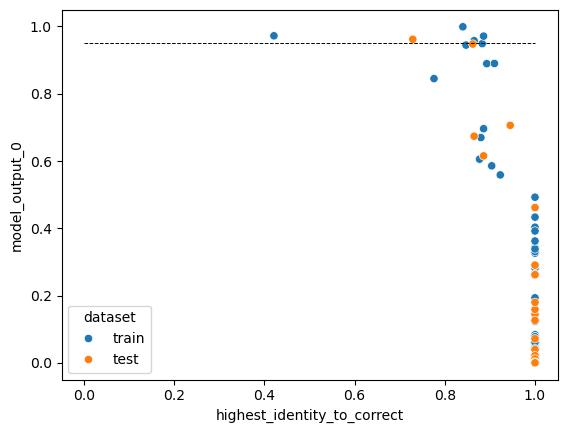

In [ ]:
fig, ax = plt.subplots()
# sns.scatterplot(data=rpoz_results_df, x='highest_bit_score_to_correct', y='model_output_0', hue='dataset', ax=ax)
sns.scatterplot(data=rpoz_results_df, x='highest_identity_to_correct', y='model_output_0', hue='dataset', ax=ax)
sns.move_legend(ax, 'lower left')
ax.hlines([0.95], xmin=0, xmax=1, color='black', ls='--', lw=0.7)


In [ ]:
# def get_weird_alignments(align_df:pd.DataFrame, dist_df:pd.DataFrame, min_distance:float=1, min_sequence_identity:float=0.7):

#     # get_mismatch_positions = lambda seqs : np.where(np.array(list(seqs[0])) != np.array(list(seqs[1])))[0]

#     df = align_df[['query_id', 'subject_id', 'sequence_identity', 'n_mismatches']].copy()
#     df = df.merge(dist_df, left_on=['query_id', 'subject_id'], right_on=['query_id', 'subject_id'], how='inner')
#     df = df[(df.distance > min_distance) & (df.sequence_identity > min_sequence_identity)].copy()

#     return df 

# rpoz_weird_df = get_weird_alignments(rpoz_align_df, rpoz_dist_df)
# rpoz_weird_df['model_output_0'] = rpoz_weird_df.query_id.map(rpoz_results_df.model_output_0)

# rpoz_weird_ids = dict()
# rpoz_weird_ids['B1Y0M2'] = ['B1Y0M2'] + list(rpoz_weird_df[rpoz_weird_df.query_id == 'B1Y0M2'].subject_id)
# rpoz_weird_ids['Q1LTY2'] = ['Q1LTY2'] + list(rpoz_weird_df[rpoz_weird_df.query_id == 'Q1LTY2'].subject_id)
# rpoz_weird_ids['A6WCB6'] = ['A6WCB6'] + list(rpoz_weird_df[rpoz_weird_df.query_id == 'A6WCB6'].subject_id)
# rpoz_weird_ids['Q741G7'] = ['Q741G7'] + list(rpoz_weird_df[rpoz_weird_df.query_id == 'Q741G7'].subject_id)
# rpoz_weird_ids['A2SJD1'] = ['A2SJD1'] + list(rpoz_weird_df[rpoz_weird_df.query_id == 'A2SJD1'].subject_id)
# rpoz_weird_ids['A9ILJ1'] = ['A9ILJ1'] + list(rpoz_weird_df[rpoz_weird_df.query_id == 'A9ILJ1'].subject_id)

# FASTAFile(df=rpoz_results_df.loc[rpoz_weird_ids['B1Y0M2']]).write('../data/results/rpoz/rpoz_biy0m2.faa')
# FASTAFile(df=rpoz_results_df.loc[rpoz_weird_ids['Q1LTY2']]).write('../data/results/rpoz/rpoz_q1lty2.faa')
# FASTAFile(df=rpoz_results_df.loc[rpoz_weird_ids['A6WCB6']]).write('../data/results/rpoz/rpoz_a6wcb6.faa')
# FASTAFile(df=rpoz_results_df.loc[rpoz_weird_ids['Q741G7']]).write('../data/results/rpoz/rpoz_q741g7.faa')
# FASTAFile(df=rpoz_results_df.loc[rpoz_weird_ids['A9ILJ1']]).write('../data/results/rpoz/rpoz_a9ilj1.faa')